# Time-dependent linear complex reciprocity test

This notebook tests only the first, linear condition in Theorem 7.1: for a linear Schrodinger-type system, reciprocity means transpose symmetry, not Hermiticity. The point is to check that the physical adjoint works when the time-dependent operator is reciprocal, even if it has imaginary damping/gain entries.

The forward dynamics are

$$
i\dot u(t)+K(t;p_K)u(t)-f(t;p_f)=0,\qquad u(0)=u_0(p_0).
$$

We use a two-mode system with explicit time dependence in the operator:

$$
K(t;p_K)=
\begin{bmatrix}
w_1+\alpha\cos(\Omega t)+i\gamma & -J+\beta\sin(\Omega t)+\rho+i\kappa\\
-J+\beta\sin(\Omega t)-\rho+i\kappa & w_2-\alpha\cos(\Omega t)+i\gamma
\end{bmatrix}.
$$

The parameter $\rho$ breaks reciprocity. If $\rho=0$, then $K(t)^T=K(t)$ for every $t$, while $K(t)$ is still generally non-Hermitian because of the imaginary entries $i\gamma$ and $i\kappa$. The drive and initial condition are also parameterized:

$$
f(t;p_f)=
\begin{bmatrix}
A_0\sin(\omega_f t)\\
A_1\cos(\omega_f t)
\end{bmatrix},
\qquad
u_0(p_0)=
\begin{bmatrix}
x_0+i y_0\\
x_1+i y_1
\end{bmatrix}.
$$

For a cost

$$
\chi[u]=\int_0^T \theta(u(t),t)\,dt + \psi(u(T)),
$$

the forward-time conjugated adjoint satisfies

$$
i\dot c(t)+K(T-t;p_K)^T c(t)+\theta_u(u(T-t),T-t)=0,
\qquad
c(0)=i\psi_u(u(T)).
$$

The physical adjoint experiment uses the same hardware operator, with the explicit time dependence reversed:

$$
i\dot c_{phys}(t)+K(T-t;p_K)c_{phys}(t)+\theta_u(u(T-t),T-t)=0.
$$

With the raw adjoint convention $a(t)=\overline{c(T-t)}$, the three gradient blocks used below are the Section 7 overlap integrals rewritten in forward time:

$$
\frac{\partial\chi}{\partial p_K}
=\int_0^T \operatorname{Re}\langle a(t),K_{p_K}(t)u(t)\rangle_C\,dt,
$$

$$
\frac{\partial\chi}{\partial p_f}
=-\int_0^T \operatorname{Re}\langle a(t),f_{p_f}(t)\rangle_C\,dt,
$$

and, for $u_{0,j}=x_j+i y_j$,

$$
\frac{\partial\chi}{\partial x_j}=-\operatorname{Im} a_j(0),
\qquad
\frac{\partial\chi}{\partial y_j}=\operatorname{Re} a_j(0).
$$

Therefore we expect:

- Reciprocal case, $\rho=0$: physical adjoint gradient matches finite differences for matrix, drive, and initial-condition parameters, even though $K$ is non-Hermitian.
- Nonreciprocal case, $\rho\ne0$: physical adjoint gradient fails.
- Digital adjoint using $K(T-t)^T$ works in both cases.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, simpson

T = 8.0
Nt = 1201
rtol = 1e-10
atol = 1e-12

initial_condition_names = ["Re u0[0]", "Re u0[1]", "Im u0[0]", "Im u0[1]"]
matrix_parameter_names = ["w1", "w2", "J", "rho", "gamma", "kappa", "alpha", "beta", "Omega"]
drive_parameter_names = ["A0", "A1", "omega_f"]
parameter_names = initial_condition_names + matrix_parameter_names + drive_parameter_names

u_target = np.array([0.10 + 0.00j, -0.85j])
q_traj = 0.5
q_T = 0.5

np.set_printoptions(precision=6, suppress=False)


In [2]:
def make_parameters(rho):
    return np.array(
        [1.00, 0.15, 0.00, 0.05]
        + [0.15, 0.55, 0.90, rho, 0.08, 0.04, 0.16, 0.12, 1.10]
        + [0.18, 0.05, 0.70],
        dtype=float,
    )


def unpack(p):
    return dict(zip(parameter_names, p))


def initial_condition(p):
    p = unpack(p)
    return np.array(
        [p["Re u0[0]"] + 1j * p["Im u0[0]"], p["Re u0[1]"] + 1j * p["Im u0[1]"]],
        dtype=complex,
    )


def K(t, p):
    p = unpack(p)
    ct = np.cos(p["Omega"] * t)
    st = np.sin(p["Omega"] * t)
    return np.array(
        [
            [p["w1"] + p["alpha"] * ct + 1j * p["gamma"],
             -p["J"] + p["beta"] * st + p["rho"] + 1j * p["kappa"]],
            [-p["J"] + p["beta"] * st - p["rho"] + 1j * p["kappa"],
             p["w2"] - p["alpha"] * ct + 1j * p["gamma"]],
        ],
        dtype=complex,
    )


def dK_dp(t, p, name):
    p = unpack(p)
    ct = np.cos(p["Omega"] * t)
    st = np.sin(p["Omega"] * t)
    out = np.zeros((2, 2), dtype=complex)

    if name == "w1":
        out[0, 0] = 1.0
    elif name == "w2":
        out[1, 1] = 1.0
    elif name == "J":
        out[0, 1] = out[1, 0] = -1.0
    elif name == "rho":
        out[0, 1] = 1.0
        out[1, 0] = -1.0
    elif name == "gamma":
        out[0, 0] = out[1, 1] = 1j
    elif name == "kappa":
        out[0, 1] = out[1, 0] = 1j
    elif name == "alpha":
        out[0, 0] = ct
        out[1, 1] = -ct
    elif name == "beta":
        out[0, 1] = out[1, 0] = st
    elif name == "Omega":
        out[0, 0] = -p["alpha"] * t * st
        out[1, 1] = p["alpha"] * t * st
        out[0, 1] = out[1, 0] = p["beta"] * t * ct

    return out


def drive(t, p):
    p = unpack(p)
    return np.array([p["A0"] * np.sin(p["omega_f"] * t), p["A1"] * np.cos(p["omega_f"] * t)], dtype=complex)


def drive_dp(t, p, name):
    p = unpack(p)
    out = np.zeros(2, dtype=complex)

    if name == "A0":
        out[0] = np.sin(p["omega_f"] * t)
    elif name == "A1":
        out[1] = np.cos(p["omega_f"] * t)
    elif name == "omega_f":
        out[0] = p["A0"] * t * np.cos(p["omega_f"] * t)
        out[1] = -p["A1"] * t * np.sin(p["omega_f"] * t)

    return out


In [3]:
def u_ref(t):
    return np.array(
        [np.cos(0.22 * np.pi * t / T), -1j * np.sin(0.37 * np.pi * t / T)],
        dtype=complex,
    )


def theta(u, t):
    r = u - u_ref(t)
    return 0.5 * q_traj * np.vdot(r, r).real


def theta_u(u, t):
    return q_traj * np.conjugate(u - u_ref(t))


def psi(uT):
    r = uT - u_target
    return 0.5 * q_T * np.vdot(r, r).real


def psi_u(uT):
    return q_T * np.conjugate(uT - u_target)


def solve_forward(p):
    t_grid = np.linspace(0.0, T, Nt)
    sol = solve_ivp(
        lambda t, u: 1j * (K(t, p) @ np.asarray(u, dtype=complex) - drive(t, p)),
        (0.0, T),
        initial_condition(p),
        t_eval=t_grid,
        dense_output=True,
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.t, sol.y, sol.sol


def cost(p):
    t, u, _ = solve_forward(p)
    return simpson([theta(u[:, k], t[k]) for k in range(t.size)], x=t) + psi(u[:, -1])


In [ ]:
def physical_adjoint_gradient(p):
    t, u, forward = solve_forward(p)
    c0 = 1j * psi_u(forward(T))

    def adjoint_source(t_adj):
        t_forward = T - t_adj
        return -theta_u(forward(t_forward), t_forward)

    def rhs(t_adj, c):
        # This is the theorem's reversed explicit time dependence: K(t) -> K(T-t).
        return 1j * (K(T - t_adj, p) @ np.asarray(c, dtype=complex) - adjoint_source(t_adj))

    c = solve_ivp(rhs, (0.0, T), c0, t_eval=t, dense_output=True, method="DOP853", rtol=rtol, atol=atol)
    if not c.success:
        raise RuntimeError(c.message)

    a = np.conjugate(c.sol(T - t))
    return overlap_gradient(t, u, a, p)


def overlap_gradient(t, u, a, p):
    gradient = []

    a0 = a[:, 0]
    gradient += [-np.imag(a0[0]), -np.imag(a0[1]), np.real(a0[0]), np.real(a0[1])]

    for name in matrix_parameter_names:
        values = [np.real(np.vdot(a[:, k], dK_dp(t[k], p, name) @ u[:, k])) for k in range(t.size)]
        gradient.append(simpson(values, x=t))

    for name in drive_parameter_names:
        values = [np.real(np.vdot(a[:, k], -drive_dp(t[k], p, name))) for k in range(t.size)]
        gradient.append(simpson(values, x=t))

    return np.array(gradient, dtype=float)


def taylor_remainder(p, gradient, h_values, direction):
    chi0 = cost(p)
    p_scale = np.mean(np.abs(p))
    return np.array([
        abs(cost(p + h * p_scale * direction) - chi0 - gradient @ (h * p_scale * direction))
        for h in h_values
    ])


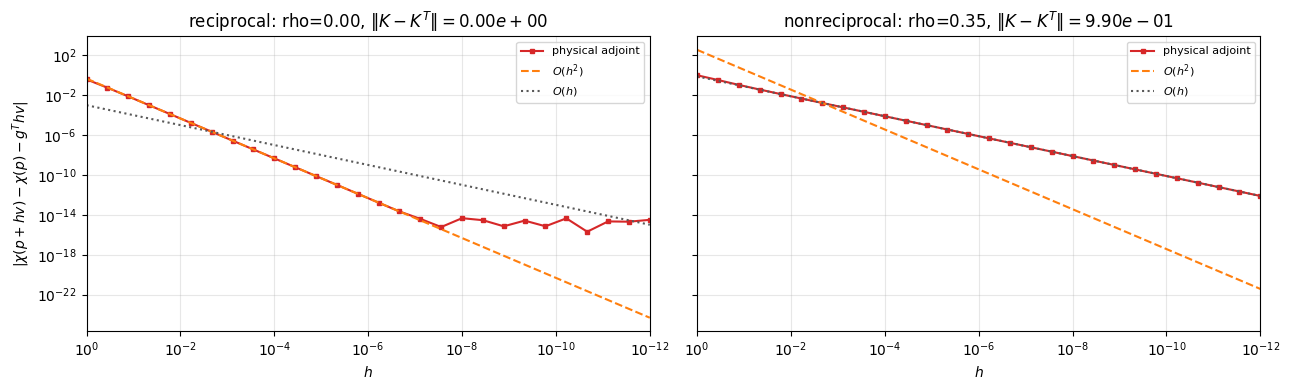

In [5]:
def run_physical_case(rho):
    p = make_parameters(rho)
    grad_physical = physical_adjoint_gradient(p)
    return p, grad_physical


rng = np.random.default_rng(2)
direction = rng.normal(size=len(parameter_names))
direction = direction / np.linalg.norm(direction)
h_values = np.logspace(0, -12, 28)

physical_results = {
    "reciprocal": run_physical_case(0.0),
    "nonreciprocal": run_physical_case(0.35),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, (label, (p, grad_physical)) in zip(axes, physical_results.items()):
    physical_errors = taylor_remainder(p, grad_physical, h_values, direction)
    anchor = 6
    ref2 = physical_errors[anchor] * (h_values / h_values[anchor]) ** 2
    ref1 = physical_errors[anchor] * (h_values / h_values[anchor])

    ax.loglog(h_values, physical_errors, "s-", ms=3, color="tab:red", label="physical adjoint")
    ax.loglog(h_values, ref2, "--", color="tab:orange", label=r"$O(h^2)$")
    ax.loglog(h_values, ref1, ":", color="0.35", label=r"$O(h)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel(r"$h$")
    ax.set_title(
        f"{label}: rho={unpack(p)['rho']:.2f}, "
        + rf"$\|K-K^T\|={np.linalg.norm(K(0.4, p) - K(0.4, p).T):.2e}$"
    )
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$|\chi(p+h v)-\chi(p)-g^T h v|$")
plt.tight_layout()
plt.show()


In [6]:
def digital_adjoint_gradient(p):
    t, u, forward = solve_forward(p)
    c0 = 1j * psi_u(forward(T))

    def adjoint_source(t_adj):
        t_forward = T - t_adj
        return -theta_u(forward(t_forward), t_forward)

    def rhs(t_adj, c):
        return 1j * (K(T - t_adj, p).T @ np.asarray(c, dtype=complex) - adjoint_source(t_adj))

    c = solve_ivp(rhs, (0.0, T), c0, t_eval=t, dense_output=True, method="DOP853", rtol=rtol, atol=atol)
    if not c.success:
        raise RuntimeError(c.message)

    a = np.conjugate(c.sol(T - t))
    return overlap_gradient(t, u, a, p)


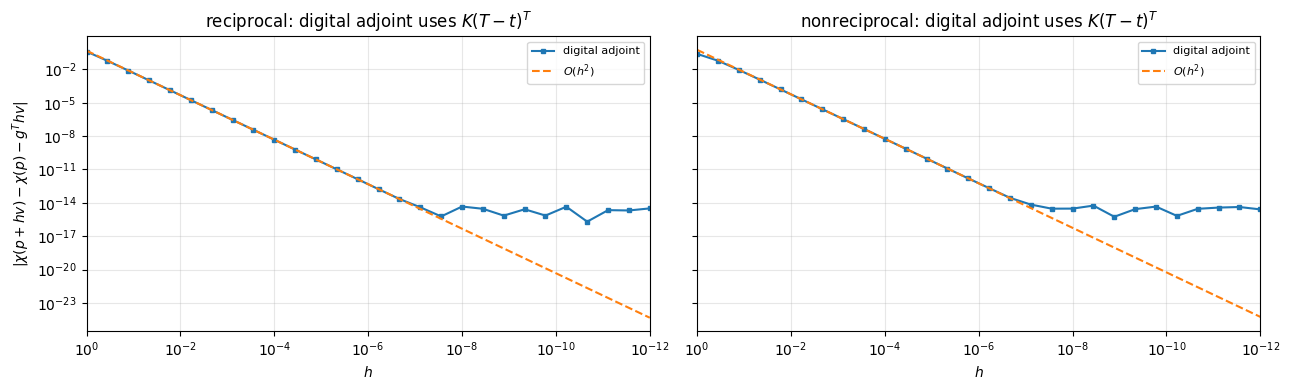

In [7]:
digital_results = {}
for label, (p, _) in physical_results.items():
    digital_results[label] = (p, digital_adjoint_gradient(p))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, (label, (p,grad_digital)) in zip(axes, digital_results.items()):
    digital_errors = taylor_remainder(p, grad_digital, h_values, direction)
    anchor = 6
    ref2 = digital_errors[anchor] * (h_values / h_values[anchor]) ** 2

    ax.loglog(h_values, digital_errors, "s-", ms=3, color="tab:blue", label="digital adjoint")
    ax.loglog(h_values, ref2, "--", color="tab:orange", label=r"$O(h^2)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel(r"$h$")
    ax.set_title(f"{label}: digital adjoint uses $K(T-t)^T$")
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$|\chi(p+h v)-\chi(p)-g^T h v|$")
plt.tight_layout()
plt.show()
